In [169]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [170]:
%pip install pandas numpy scikit-learn pgmpy

Note: you may need to restart the kernel to use updated packages.


In [171]:
%pip install --upgrade pgmpy

Note: you may need to restart the kernel to use updated packages.


In [172]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [173]:
from sklearn.utils import resample

In [174]:
import pgmpy.estimators as estimators
print(dir(estimators))

['AIC', 'AICCondGauss', 'AICGauss', 'BDeu', 'BDs', 'BIC', 'BICCondGauss', 'BICGauss', 'BaseConstraintEstimator', 'BaseEstimator', 'BayesianEstimator', 'CITests', 'EM', 'ExhaustiveSearch', 'ExpectationMaximization', 'ExpertInLoop', 'ExpertKnowledge', 'GES', 'HillClimbSearch', 'IVEstimator', 'K2', 'LinearModel', 'LogLikelihoodCondGauss', 'LogLikelihoodGauss', 'MLE', 'MarginalEstimator', 'MaximumLikelihoodEstimator', 'MirrorDescentEstimator', 'MmhcEstimator', 'PC', 'ParameterEstimator', 'SEMEstimator', 'ScoreCache', 'StructureEstimator', 'StructureScore', 'TreeSearch', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__warningregistry__', 'base', 'expert']


In [175]:
from pgmpy.estimators import HillClimbSearch, AIC
from pgmpy.estimators import BIC

In [176]:
engineSensor = pd.read_csv(r'C:\Users\User\Desktop\MASTERS WLV\Application of Intelligent agent\project\cleaned_data (1).csv')

In [177]:
engineSensor.head(5)

,TimeStamp,Ambient Temperature,Distance Travelled,Engine Coolant Temperature,Engine Fuel Rate,Engine Intake Manifold Pressure,Engine Intake Manifold Temperature,Engine Oil Pressure,Engine Oil Temperature,Engine RPM,Idle,Machine Running Hours,Machine Speed,Operational,Transmission Hours,Transmission Oil Pressure,Transmission Oil Temperature,status
0,01/09/2016 19:10,18.0,68747.901,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10289.77728,0.0,0.0,7631.700765,0.1,0.0,1
1,01/09/2016 19:10,18.0,68747.901,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10289.77728,0.0,0.0,7631.700765,0.1,0.0,1
2,01/09/2016 19:10,18.0,68747.901,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10289.77728,0.0,0.0,7631.700765,0.1,0.0,1
3,01/09/2016 19:10,18.0,68747.901,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10289.77728,0.0,0.0,7631.700765,0.0,0.0,1
4,01/09/2016 19:10,18.0,68747.901,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10289.77728,0.0,0.0,7631.700765,0.1,0.0,1


In [178]:
engineSensor= engineSensor.drop_duplicates()

In [222]:
engineSensor = engineSensor.dropna()

In [223]:
engineSensor.shape

(540149, 18)

In [180]:
engineNecessary = engineSensor.drop(['TimeStamp', 'Distance Travelled'], axis=1)

CONVERT CONTINIOUS DATA INTO CATEGORY

In [181]:
engineNecessary['RPM_Level']= pd.cut(engineNecessary['Engine RPM'], bins=[0, 800, 2000, 3500], labels=['Low', 'Medium', 'High'])
engineNecessary['Engine_Oil_Temp_level']= pd.cut(engineNecessary['Engine Oil Temperature'], bins=[0, 50, 100, 150], labels=['Low', 'Medium', 'High'])
engineNecessary['Engine_Coolant_Temp_level']= pd.cut(engineNecessary['Engine Coolant Temperature'], bins=[0, 50, 100, 150], labels=['Low', 'Medium', 'High'])
engineNecessary['Engine_Intake_Manifold_Press_level']= pd.cut(engineNecessary['Engine Intake Manifold Pressure'], bins=[0, 1,2,3], labels=['Low', 'Medium', 'High'])
engineNecessary['Engine_Intake_Manifold_Temp_level']= pd.cut(engineNecessary['Engine Intake Manifold Temperature'], bins=[0, 30, 70, 100], labels=['Low', 'Medium', 'High'])
engineNecessary['Ambient_Temp_Level']= pd.cut(engineNecessary['Ambient Temperature'], bins=[0, 10, 20, 40], labels=['Low', 'Medium', 'High'])
engineNecessary['Engine_Oil_Press_level']= pd.cut(engineNecessary['Engine Oil Pressure'], bins=[0, 2, 5, 10], labels=['Low', 'Medium', 'High'])
engineNecessary['Machine_Speed_Level']= pd.cut(engineNecessary['Machine Speed'], bins=[0, 10, 20, 30], labels=['Low', 'Medium', 'High'])
engineNecessary['Transmission_Oil_Press_level']= pd.cut(engineNecessary['Transmission Oil Pressure'], bins=[0, 10, 20, 30], labels=['Low', 'Medium', 'High'])
engineNecessary['Transmission_Oil_Temp_level']= pd.cut(engineNecessary['Transmission Oil Temperature'], bins=[0, 50, 100, 150], labels=['Low', 'Medium', 'High'])
engineNecessary['Operating_Status']= pd.cut(engineNecessary['Operational'], bins=[0, 0.5, 1], labels=['No', 'Yes'])
#engineNecessary['status'] = engineNecessary['status'].replace({1: 'Normal', -1: 'Fault'})






In [182]:
engineNecessary.head(5)

,Ambient Temperature,Engine Coolant Temperature,Engine Fuel Rate,Engine Intake Manifold Pressure,Engine Intake Manifold Temperature,Engine Oil Pressure,Engine Oil Temperature,Engine RPM,Idle,Machine Running Hours,...,Engine_Oil_Temp_level,Engine_Coolant_Temp_level,Engine_Intake_Manifold_Press_level,Engine_Intake_Manifold_Temp_level,Ambient_Temp_Level,Engine_Oil_Press_level,Machine_Speed_Level,Transmission_Oil_Press_level,Transmission_Oil_Temp_level,Operating_Status
0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10289.77728,...,NaN,NaN,NaN,NaN,Medium,NaN,NaN,Low,NaN,NaN
3,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10289.77728,...,NaN,NaN,NaN,NaN,Medium,NaN,NaN,NaN,NaN,NaN
12,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10289.77728,...,NaN,NaN,NaN,NaN,Medium,NaN,NaN,NaN,NaN,NaN
13,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10289.77728,...,NaN,NaN,NaN,NaN,Medium,NaN,NaN,Low,NaN,NaN
24,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10289.77728,...,NaN,NaN,NaN,NaN,Medium,NaN,NaN,Low,NaN,NaN


In [183]:
#engineDataStructured = engineNecessary.drop(['Engine RPM','Engine Oil Temperature','Engine Coolant Temperature','Engine Intake Manifold Pressure','Engine Intake Manifold Temperature'
 #                                            ,'Ambient Temperature','Engine Oil Pressure','Machine Speed','Transmission Oil Pressure','Transmission Oil Temperature','Engine Fuel Rate', 'Idle', 'Machine Running Hours', 'Operational', 'Transmission Hours','status'],axis=1)

In [184]:
engineNecessary['status'] = engineNecessary['status'].map({
    1:'Normal',
   -1:'Fault'
})

In [185]:
print(engineNecessary['status'])


0         Normal
3         Normal
12        Normal
13        Normal
24        Normal
           ...  
599538    Normal
599539    Normal
599540    Normal
599541    Normal
599542    Normal
Name: status, Length: 540149, dtype: str


In [186]:
print(len(engineNecessary['status'] == '1'), len(engineNecessary['status']== '-1'))

540149 540149


In [187]:
engineNecessary.shape

(540149, 27)

In [188]:
count_normal = (engineNecessary['status'] == 'Normal').sum()
count_fault = (engineNecessary['status'] == 'Fault').sum()
print(count_normal)
print(count_fault)

520579
19570


Balance the Data with status fault and status normal

In [189]:
normal = engineNecessary[engineNecessary['status'] == 'Normal']
fault = engineNecessary[engineNecessary['status'] == 'Fault']

count_normal = len(normal)
count_fault = len(fault)

normal_downsampled = resample(
    normal,
    replace=False,
    n_samples=count_fault,
    random_state=42
)

balanced_Eng_df = pd.concat([normal_downsampled, fault])
print(balanced_Eng_df.shape)

(39140, 27)


In [190]:
balanced_Eng_df.head(5)

,Ambient Temperature,Engine Coolant Temperature,Engine Fuel Rate,Engine Intake Manifold Pressure,Engine Intake Manifold Temperature,Engine Oil Pressure,Engine Oil Temperature,Engine RPM,Idle,Machine Running Hours,...,Engine_Oil_Temp_level,Engine_Coolant_Temp_level,Engine_Intake_Manifold_Press_level,Engine_Intake_Manifold_Temp_level,Ambient_Temp_Level,Engine_Oil_Press_level,Machine_Speed_Level,Transmission_Oil_Press_level,Transmission_Oil_Temp_level,Operating_Status
313466,31.7,80.0,11.40,0.02,65.0,2.08,80.0,678.0,1.0,10660.19414,...,Medium,Medium,Low,Medium,High,Medium,NaN,Medium,Medium,NaN
168890,25.8,86.0,27.55,0.58,75.0,4.48,86.0,2278.0,0.0,10482.62549,...,Medium,Medium,Low,High,High,Medium,Medium,Medium,Medium,Yes
270670,27.7,85.0,140.00,2.12,69.0,4.36,85.0,2038.0,0.0,10610.97020,...,Medium,Medium,High,Medium,High,Medium,Low,High,Medium,Yes
355932,27.7,83.0,79.25,1.20,70.0,4.64,83.0,2284.0,0.0,10714.71905,...,Medium,Medium,Medium,Medium,High,Medium,Low,Medium,Medium,Yes
531551,27.7,83.0,12.70,0.24,67.0,4.84,83.0,2064.0,0.0,10927.29272,...,Medium,Medium,Low,Medium,High,Medium,High,Medium,High,Yes


In [191]:
balanced_Eng_df.shape

(39140, 27)

In [192]:
balanced_Eng_df = balanced_Eng_df.drop(['Engine RPM','Engine Oil Temperature','Engine Coolant Temperature','Engine Intake Manifold Pressure','Engine Intake Manifold Temperature'
                                             ,'Ambient Temperature','Engine Oil Pressure','Machine Speed','Transmission Oil Pressure','Transmission Oil Temperature','Engine Fuel Rate', 'Idle', 'Machine Running Hours', 'Operational','Operating_Status', 'Transmission Hours'],axis=1)

In [193]:
balanced_Eng_df.shape

(39140, 11)

BUILD NETWORK DATA STRUCTURE TO SHOW DEPENDENCE OF DATA

In [194]:
from pgmpy.estimators import HillClimbSearch, K2

balanced_Eng_df = balanced_Eng_df.dropna()
hc = HillClimbSearch(balanced_Eng_df)

K2_model = hc.estimate(
    scoring_method=K2(balanced_Eng_df)
)

C:\Users\User\AppData\Local\Temp\ipykernel_22432\3192223431.py:4: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(balanced_Eng_df)
  0%|          | 51/1000000 [00:04<25:26:50, 10.92it/s]


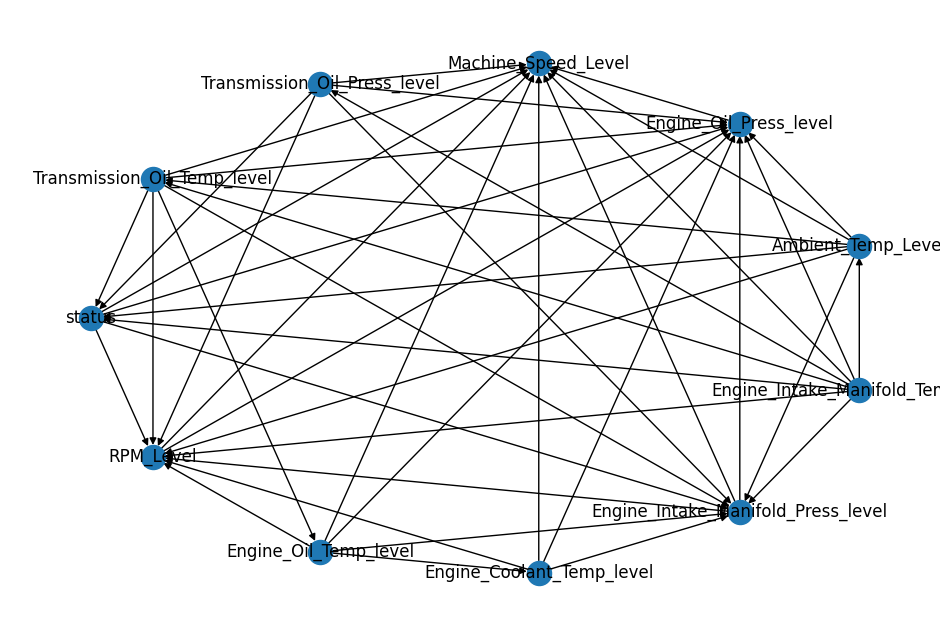

In [195]:
import networkx as nx

import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

pos = nx.shell_layout(K2_model) # Changed to shell_layout

nx.draw_networkx(
    K2_model,
    pos=pos,
    arrows=True
)

plt.axis("off")
plt.show()

In [196]:
from pgmpy.estimators import BDeu, HillClimbSearch

balanced_Eng_df = balanced_Eng_df.dropna()
hc = HillClimbSearch(balanced_Eng_df)

BDeu_model = hc.estimate(
    scoring_method=BDeu(balanced_Eng_df)
)

C:\Users\User\AppData\Local\Temp\ipykernel_22432\4207960633.py:4: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(balanced_Eng_df)
  0%|          | 32/1000000 [00:03<33:20:45,  8.33it/s]


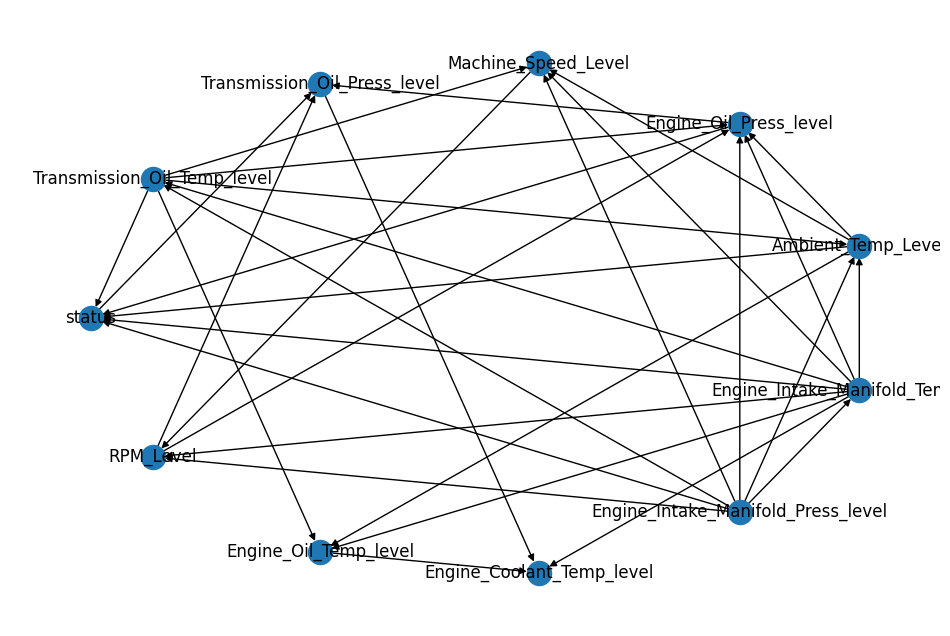

In [197]:
import networkx as nx

import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

pos = nx.shell_layout(BDeu_model) # Changed to shell_layout

nx.draw_networkx(
    BDeu_model,
    pos=pos,
    arrows=True
)

plt.axis("off")
plt.show()

In [198]:
from pgmpy.estimators import HillClimbSearch, AIC
from pgmpy.estimators import BIC

# Drop rows with any NaN values to ensure clean data for HillClimbSearch
balanced_Eng_df = balanced_Eng_df.dropna()

hc = HillClimbSearch(balanced_Eng_df)

BIC_model = hc.estimate(
    scoring_method=BIC(balanced_Eng_df),
    max_indegree=3
)

C:\Users\User\AppData\Local\Temp\ipykernel_22432\1429094514.py:7: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(balanced_Eng_df)
  0%|          | 19/1000000 [00:02<39:34:05,  7.02it/s]


In [199]:
print(BIC_model)

DAG with 11 nodes and 19 edges


In [200]:
%pip install networkx


Note: you may need to restart the kernel to use updated packages.


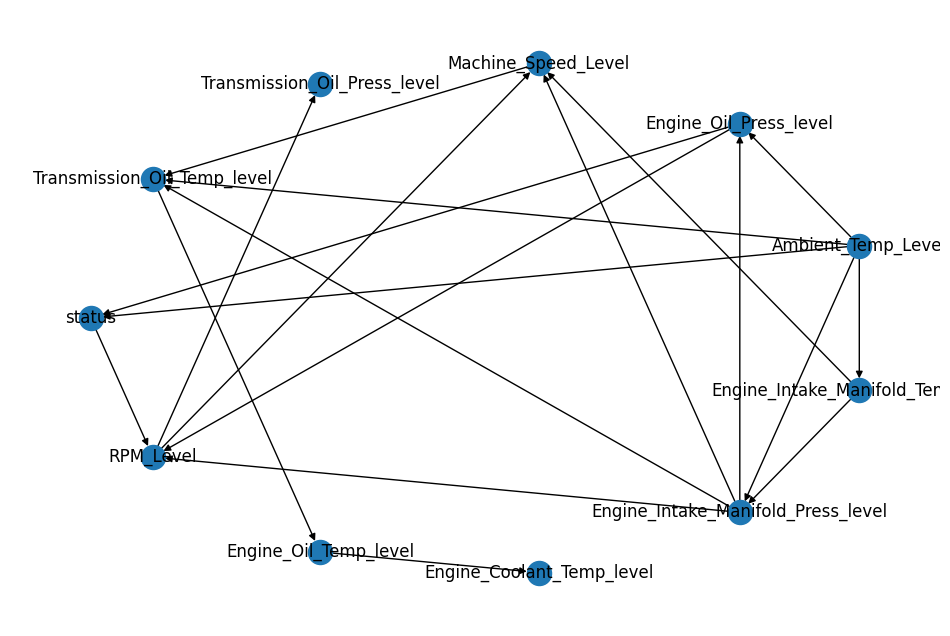

In [201]:
import networkx as nx

import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

pos = nx.shell_layout(BIC_model) # Changed to shell_layout

nx.draw_networkx(
    BIC_model,
    pos=pos,
    arrows=True
)

plt.axis("off")
plt.show()

learn the Conditional Probability Tables (CPTs)

In [202]:
print(list(K2_model.edges())[:10])

[('status', 'Machine_Speed_Level'), ('status', 'Engine_Oil_Press_level'), ('status', 'Engine_Intake_Manifold_Press_level'), ('status', 'RPM_Level'), ('RPM_Level', 'Machine_Speed_Level'), ('RPM_Level', 'Engine_Oil_Press_level'), ('Engine_Oil_Temp_level', 'Engine_Coolant_Temp_level'), ('Engine_Oil_Temp_level', 'Machine_Speed_Level'), ('Engine_Oil_Temp_level', 'Engine_Oil_Press_level'), ('Engine_Oil_Temp_level', 'RPM_Level')]


In [203]:
print(engineNecessary['status'].unique())

<StringArray>
['Normal', 'Fault']
Length: 2, dtype: str


In [204]:
print(engineNecessary['Operating_Status'].unique())

[NaN, 'Yes', 'No']
Categories (2, str): ['No' < 'Yes']


In [205]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    balanced_Eng_df,
    test_size=0.1,
    random_state=42,
    stratify=balanced_Eng_df["status"]
)

In [206]:
from pgmpy.estimators import BayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork

In [229]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE # Correct import for DiscreteMLE

bayesian_model = DiscreteBayesianNetwork(K2_model.edges())

# Instantiate DiscreteMLE without passing model or data here
estimator_instance = DiscreteMLE()

bayesian_model.fit(
    train_df,
    estimator=estimator_instance,
    
)
test_score = K2(test_df).score(bayesian_model)
print("Test score K2:", test_score)

Test score K2: 3175.550735749958


In [208]:
bayesian_model_DBeu = DiscreteBayesianNetwork(BDeu_model.edges())
estimator_instance_DBeu = DiscreteMLE()
bayesian_model_DBeu.fit(
    train_df, estimator=estimator_instance_DBeu
)
test_score_DBeu = BDeu(test_df).score(bayesian_model_DBeu)
print("Test score DBeu:", test_score_DBeu)

Test score DBeu: -8408.976458988047


In [209]:
bayesian_model_BIC = DiscreteBayesianNetwork(BIC_model.edges())
estimator_instance_BIC = DiscreteMLE()
bayesian_model_BIC.fit(
    train_df, estimator=estimator_instance_BIC
)
test_score_BIC = BIC(test_df).score(bayesian_model_BIC)
print("Test score BIC:", test_score_BIC)

Test score BIC: -8692.730784148263


In [210]:
from pgmpy.estimators import MaximumLikelihoodEstimator

In [211]:
balanced_Eng_df.dtypes

status                                     str
RPM_Level                             category
Engine_Oil_Temp_level                 category
Engine_Coolant_Temp_level             category
Engine_Intake_Manifold_Press_level    category
Engine_Intake_Manifold_Temp_level     category
Ambient_Temp_Level                    category
Engine_Oil_Press_level                category
Machine_Speed_Level                   category
Transmission_Oil_Press_level          category
Transmission_Oil_Temp_level           category
dtype: object

In [224]:
for cpd in bayesian_model.get_cpds():
    print(cpd.state_names)

{'status': ['Fault', 'Normal'], 'Ambient_Temp_Level': ['High', 'Low', 'Medium'], 'Engine_Intake_Manifold_Temp_level': ['High', 'Low', 'Medium'], 'Transmission_Oil_Press_level': ['High', 'Low', 'Medium'], 'Transmission_Oil_Temp_level': ['High', 'Low', 'Medium']}
{'Machine_Speed_Level': ['High', 'Low', 'Medium'], 'Ambient_Temp_Level': ['High', 'Low', 'Medium'], 'Engine_Coolant_Temp_level': ['High', 'Low', 'Medium'], 'Engine_Intake_Manifold_Press_level': ['High', 'Low', 'Medium'], 'Engine_Intake_Manifold_Temp_level': ['High', 'Low', 'Medium'], 'Engine_Oil_Press_level': ['High', 'Low', 'Medium'], 'Engine_Oil_Temp_level': ['High', 'Low', 'Medium'], 'RPM_Level': ['High', 'Low', 'Medium'], 'Transmission_Oil_Press_level': ['High', 'Low', 'Medium'], 'Transmission_Oil_Temp_level': ['High', 'Low', 'Medium'], 'status': ['Fault', 'Normal']}
{'Engine_Oil_Press_level': ['High', 'Low', 'Medium'], 'Ambient_Temp_Level': ['High', 'Low', 'Medium'], 'Engine_Coolant_Temp_level': ['High', 'Low', 'Medium'], '

In [212]:
for cpt in bayesian_model.get_cpds():
    print(cpt)

+-----------------------------------+-----+
| Ambient_Temp_Level                | ... |
+-----------------------------------+-----+
| Engine_Intake_Manifold_Temp_level | ... |
+-----------------------------------+-----+
| Transmission_Oil_Press_level      | ... |
+-----------------------------------+-----+
| Transmission_Oil_Temp_level       | ... |
+-----------------------------------+-----+
| status(Fault)                     | ... |
+-----------------------------------+-----+
| status(Normal)                    | ... |
+-----------------------------------+-----+
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
+-----+
| ..

In [213]:
y_test = test_df['status']

In [214]:
from pgmpy.inference import VariableElimination

# Inference engine
infer = VariableElimination(bayesian_model)

# Predict status for each test sample
predictions = []
for idx, row in test_df.iterrows():
    # Evidence: all columns except 'status'
    evidence = {col: row[col] for col in test_df.columns if col != 'status'}
    
    # Skip if any evidence value is NaN
    if any(pd.isna(v) for v in evidence.values()):
        predictions.append(None)
        continue
    
    # Query the status variable
    try:
        prob = infer.query(variables=['status'], evidence=evidence)
        # Get the state with highest probability
        pred = prob.state_names['status'][prob.values.argmax()]
        predictions.append(pred)
    except:
        predictions.append(None)

# Convert to array
y_pred = np.array(predictions)
y_test_vals = y_test.values

# Remove None predictions
mask = y_pred != None
y_pred_clean = y_pred[mask]
y_test_clean = y_test_vals[mask]

print(f"Predictions made: {mask.sum()} / {len(mask)}")

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pgmpy\factors\discrete\DiscreteFactor.py:516: RuntimeWarning: invalid value encountered in divide
  phi.values = phi.values / (phi.values.sum())


Predictions made: 1883 / 1883


In [215]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test_clean, y_pred_clean)
precision = precision_score(y_test_clean, y_pred_clean, labels=['Normal', 'Fault'], average='weighted', zero_division=0)
recall = recall_score(y_test_clean, y_pred_clean, labels=['Normal', 'Fault'], average='weighted', zero_division=0)
f1 = f1_score(y_test_clean, y_pred_clean, labels=['Normal', 'Fault'], average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_clean, y_pred_clean, labels=['Normal', 'Fault'])
print(f"\nConfusion Matrix:\n{cm}")

Accuracy:  0.7562
Precision: 0.7568
Recall:    0.7562
F1 Score:  0.7216

Confusion Matrix:
[[1232   61]
 [ 398  192]]


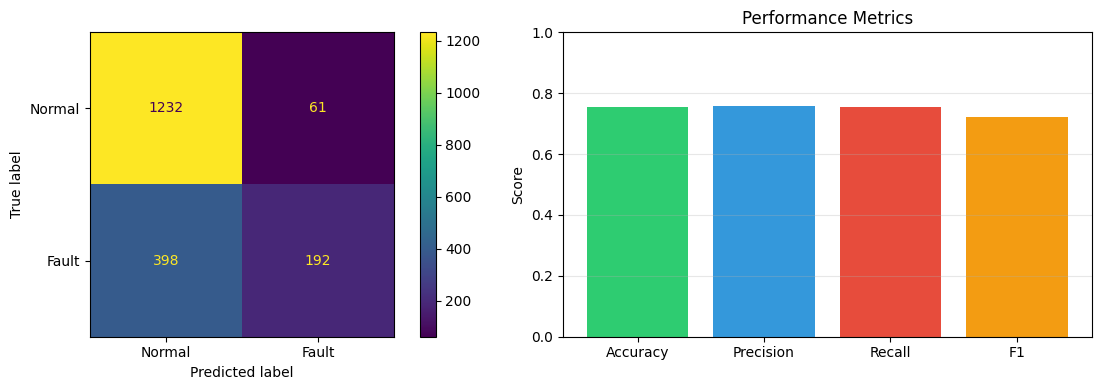

In [216]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fault']).plot(ax=axes[0])

# Metrics bar chart
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1}
axes[1].bar(metrics.keys(), metrics.values(), color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Score')
axes[1].set_title('Performance Metrics')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Querying the Probability of 'status'

We can now query the model to get the marginal probability distribution of the 'status' variable.

In [217]:
from pgmpy.inference import VariableElimination

# Create an inference object
inference = VariableElimination(bayesian_model)

# Query the marginal probability of 'status'
prob_status = inference.query(variables=['status'])

# Print the result
print(prob_status)

+----------------+---------------+
| status         |   phi(status) |
+================+===============+
| status(Fault)  |        0.3132 |
+----------------+---------------+
| status(Normal) |        0.6868 |
+----------------+---------------+


### Conditional Probability Query

Now, let's find the conditional probability of 'status' given a specific sensor level. For example, what is the probability of 'status' (Fault or Normal) when 'RPM_Level' is 'High'?

In [218]:
# Query the conditional probability of 'status' given 'RPM_Level' is 'High'
prob_status_given_rpm_high = inference.query(variables=['status'], evidence={'RPM_Level': 'High', })

# Print the result
print(prob_status_given_rpm_high)

+----------------+---------------+
| status         |   phi(status) |
+================+===============+
| status(Fault)  |        0.3416 |
+----------------+---------------+
| status(Normal) |        0.6584 |
+----------------+---------------+


### Conditional Probability for 'status' given 'Engine Oil Temp_level' is 'Medium'

In [219]:
# Query the conditional probability of 'status' given 'Engine Oil Temp_level' is 'Medium'
prob_status_given_oil_temp_medium = inference.query(variables=['status'], evidence={'Engine_Oil_Temp_level': 'Medium'})

# Print the result
print(prob_status_given_oil_temp_medium)

+----------------+---------------+
| status         |   phi(status) |
+================+===============+
| status(Fault)  |        0.3121 |
+----------------+---------------+
| status(Normal) |        0.6879 |
+----------------+---------------+


### Conditional Probability for 'status' given 'Engine Coolant Temp_level' is 'High'

In [232]:
# Query the conditional probability of 'status' given 'Engine Coolant Temp_level' is 'High'
prob_status_given_coolant_temp_high = inference.query(variables=['status'], evidence={ 'Engine_Intake_Manifold_Temp_level':'High','Engine_Intake_Manifold_Press_level':'High','RPM_Level':'Medium','Engine_Oil_Press_level':'Medium','Engine_Coolant_Temp_level': 'High', 'Transmission_Oil_Temp_level':'Low','Transmission_Oil_Press_level':'High','Machine_Speed_Level':'Low'})

# Print the result

print(prob_status_given_coolant_temp_high)

+----------------+---------------+
| status         |   phi(status) |
+================+===============+
| status(Fault)  |           nan |
+----------------+---------------+
| status(Normal) |           nan |
+----------------+---------------+


### Conditional Probability for 'status' given multiple evidence ('RPM_Level': 'Low', 'Engine Oil Temp_level': 'Low')

In [ ]:
# Query the conditional probability of 'status' given 'RPM_Level' is 'Low' and 'Engine_Oil_Temp_level' is 'Low'
prob_status_given_rpm_low_oil_low = inference.query(variables=['status'], evidence={'RPM_Level': 'Low', 'Engine_Oil_Temp_level': 'Low'})

# Print the result
print(prob_status_given_rpm_low_oil_low)

+----------------+---------------+
| status         |   phi(status) |
+================+===============+
| status(Fault)  |        0.9624 |
+----------------+---------------+
| status(Normal) |        0.0376 |
+----------------+---------------+


In [ ]:
test_score = K2(test_df).score(bayesian_model)
print("Test score:", test_score)

Test score: 3175.550735749958


In [ ]:
import pickle

In [ ]:
with open('C:\\Users\\User\\Desktop\\MASTERS WLV\\Application of Intelligent agent\\Assignment\\project\\K2BayesianModel.pkl', 'wb') as file:
    pickle.dump(bayesian_model, file)    

In [ ]:
from pgmpy.readwrite import BIFWriter

writer = BIFWriter(bayesian_model)
writer.write_bif('C:\\Users\\User\\Desktop\\MASTERS WLV\\Application of Intelligent agent\\Assignment\\project\\engine_fault_model.bif')

C:\Users\User\AppData\Local\Temp\ipykernel_22432\3535167651.py:4: FutureWarning: `BIFWriter.write_bif` is deprecated and will be removed in v1.3.0. Please use `BIFWriter.write` instead.
  writer.write_bif('C:\\Users\\User\\Desktop\\MASTERS WLV\\Application of Intelligent agent\\Assignment\\project\\engine_fault_model.bif')
